In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)

np.random.seed(42)

In [3]:
df = pd.read_csv('train.csv')
print("Shape:", df.shape)
df.head()

Shape: (188533, 13)


,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   id            188533 non-null  int64
 1   brand         188533 non-null  str  
 2   model         188533 non-null  str  
 3   model_year    188533 non-null  int64
 4   milage        188533 non-null  int64
 5   fuel_type     183450 non-null  str  
 6   engine        188533 non-null  str  
 7   transmission  188533 non-null  str  
 8   ext_col       188533 non-null  str  
 9   int_col       188533 non-null  str  
 10  accident      186081 non-null  str  
 11  clean_title   167114 non-null  str  
 12  price         188533 non-null  int64
dtypes: int64(4), str(9)
memory usage: 18.7 MB


In [5]:
df.describe()

,id,model_year,milage,price
count,188533.000000,188533.000000,188533.000000,1.885330e+05
mean,94266.000000,2015.829998,65705.295174,4.387802e+04
std,54424.933488,5.660967,49798.158076,7.881952e+04
min,0.000000,1974.000000,100.000000,2.000000e+03
25%,47133.000000,2013.000000,24115.000000,1.700000e+04
50%,94266.000000,2017.000000,57785.000000,3.082500e+04
75%,141399.000000,2020.000000,95400.000000,4.990000e+04
max,188532.000000,2024.000000,405000.000000,2.954083e+06


In [6]:
cat_cols = ['brand', 'fuel_type', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title']
for c in cat_cols:
    print(f"--- {c} : {df[c].nunique()} unique values ---")
    print(df[c].value_counts(dropna=False).head(5))
    print()

--- brand : 57 unique values ---
brand
Ford             23088
Mercedes-Benz    19172
BMW              17028
Chevrolet        16335
Audi             10887
Name: count, dtype: int64

--- fuel_type : 7 unique values ---
fuel_type
Gasoline         165940
Hybrid             6832
E85 Flex Fuel      5406
NaN                5083
Diesel             3955
Name: count, dtype: int64

--- transmission : 52 unique values ---
transmission
A/T                               49904
8-Speed A/T                       20645
Transmission w/Dual Shift Mode    19255
6-Speed A/T                       18044
6-Speed M/T                       11998
Name: count, dtype: int64

--- ext_col : 319 unique values ---
ext_col
Black     48658
White     43815
Gray      25293
Silver    16995
Blue      14555
Name: count, dtype: int64

--- int_col : 156 unique values ---
int_col
Black    107674
Beige     24495
Gray      21204
Brown      5810
Red        5145
Name: count, dtype: int64

--- accident : 2 unique values ---
accident


In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_count', ascending=False)
missing_df

,missing_count,missing_pct
clean_title,21419,11.36
fuel_type,5083,2.70
accident,2452,1.30


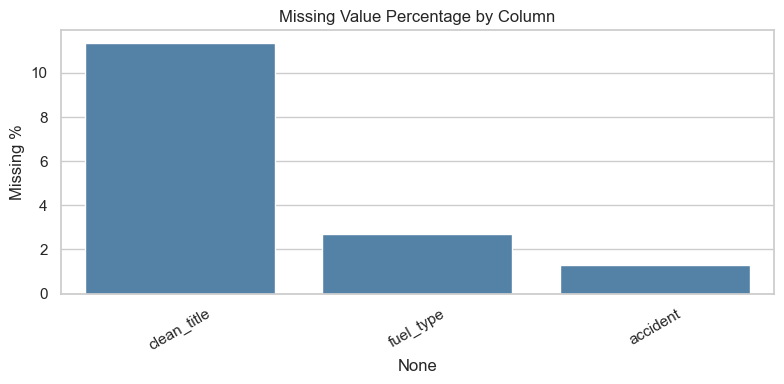

In [8]:
plt.figure(figsize=(8, 4))
sns.barplot(x=missing_df.index, y=missing_df['missing_pct'], color='steelblue')
plt.ylabel('Missing %')
plt.title('Missing Value Percentage by Column')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [9]:
df['fuel_type'] = df['fuel_type'].replace('\u2013', np.nan)
df['fuel_type'] = df['fuel_type'].fillna('Unknown')

df['accident'] = df['accident'].fillna('Unknown')

df['clean_title'] = df['clean_title'].fillna('Unknown')

print("Remaining missing values:\n", df.isnull().sum().sum())

Remaining missing values:
 0


In [10]:
CURRENT_YEAR = 2026
df['car_age'] = CURRENT_YEAR - df['model_year']

def extract_hp(text):
    m = re.search(r'([\d.]+)\s*HP', text)
    return float(m.group(1)) if m else np.nan

def extract_liters(text):
    m = re.search(r'([\d.]+)\s*L\b', text)
    return float(m.group(1)) if m else np.nan

def extract_cylinders(text):
    m = re.search(r'(\d+)\s*Cylinder', text)
    if m:
        return int(m.group(1))
    if 'V6' in text or 'Straight 6' in text:
        return 6
    if 'V8' in text:
        return 8
    if 'V12' in text:
        return 12
    return np.nan

df['horsepower'] = df['engine'].apply(extract_hp)
df['engine_liters'] = df['engine'].apply(extract_liters)
df['cylinders'] = df['engine'].apply(extract_cylinders)

for col in ['horsepower', 'engine_liters', 'cylinders']:
    df[col] = df[col].fillna(df[col].median())

def simplify_transmission(t):
    t = t.upper()
    if 'M/T' in t or 'MANUAL' in t:
        return 'Manual'
    if 'A/T' in t or 'AUTOMATIC' in t or 'CVT' in t or 'DUAL SHIFT' in t:
        return 'Automatic'
    return 'Other'

df['transmission_type'] = df['transmission'].apply(simplify_transmission)

top_brands = df['brand'].value_counts().nlargest(15).index
df['brand_grouped'] = df['brand'].where(df['brand'].isin(top_brands), 'Other')

df['accident_reported'] = (df['accident'] == 'At least 1 accident or damage reported').astype(int)
df['clean_title_flag'] = (df['clean_title'] == 'Yes').astype(int)

df[['car_age', 'horsepower', 'engine_liters', 'cylinders', 'transmission_type', 'brand_grouped']].head()

,car_age,horsepower,engine_liters,cylinders,transmission_type,brand_grouped
0,19,172.0,1.6,4.0,Automatic,Other
1,24,252.0,3.9,8.0,Automatic,Other
2,24,320.0,5.3,8.0,Automatic,Chevrolet
3,9,420.0,5.0,8.0,Automatic,Other
4,5,208.0,2.0,4.0,Automatic,Mercedes-Benz


In [11]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

for col in ['price', 'milage', 'horsepower']:
    low, high = iqr_bounds(df[col])
    n_out = ((df[col] < low) | (df[col] > high)).sum()
    print(f"{col}: bounds=({low:.1f}, {high:.1f}), outliers={n_out} ({n_out/len(df)*100:.2f}%)")

price: bounds=(-32350.0, 99250.0), outliers=10880 (5.77%)
milage: bounds=(-82812.5, 202327.5), outliers=1766 (0.94%)
horsepower: bounds=(107.5, 567.5), outliers=5696 (3.02%)


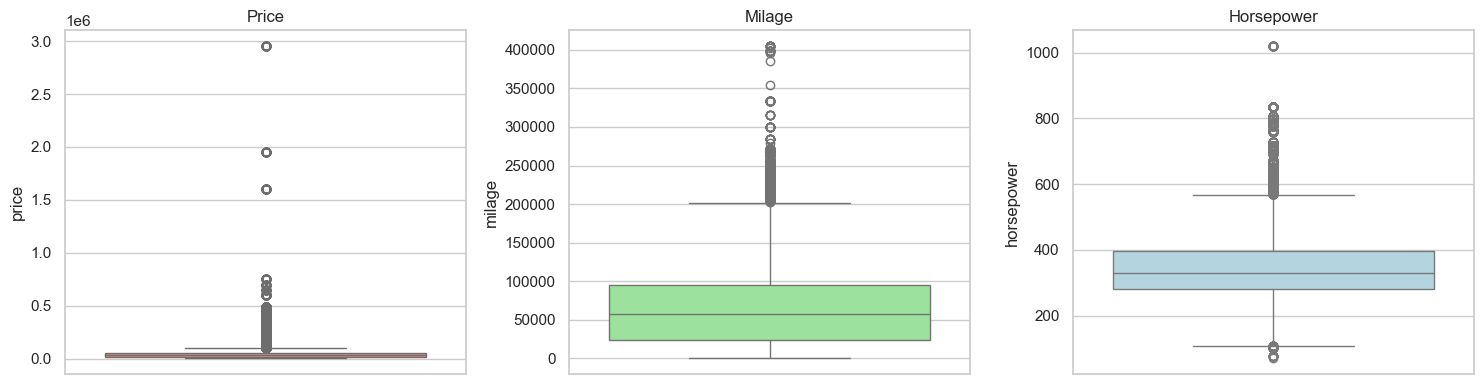

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(y=df['price'], ax=axes[0], color='salmon')
axes[0].set_title('Price')
sns.boxplot(y=df['milage'], ax=axes[1], color='lightgreen')
axes[1].set_title('Milage')
sns.boxplot(y=df['horsepower'], ax=axes[2], color='lightblue')
axes[2].set_title('Horsepower')
plt.tight_layout()
plt.show()

In [13]:
def winsorize(series, lower=0.01, upper=0.99):
    lo, hi = series.quantile(lower), series.quantile(upper)
    return series.clip(lo, hi)

df['price_capped'] = winsorize(df['price'])
df['milage_capped'] = winsorize(df['milage'])
df['horsepower_capped'] = winsorize(df['horsepower'])

print(df[['price', 'price_capped', 'milage', 'milage_capped']].describe())

              price   price_capped         milage  milage_capped
count  1.885330e+05  188533.000000  188533.000000  188533.000000
mean   4.387802e+04   41182.284465   65705.295174   65395.150292
std    7.881952e+04   40069.975203   49798.158076   48719.135063
min    2.000000e+03    4000.000000     100.000000    1087.000000
25%    1.700000e+04   17000.000000   24115.000000   24115.000000
50%    3.082500e+04   30825.000000   57785.000000   57785.000000
75%    4.990000e+04   49900.000000   95400.000000   95400.000000
max    2.954083e+06  259500.000000  405000.000000  201509.000000


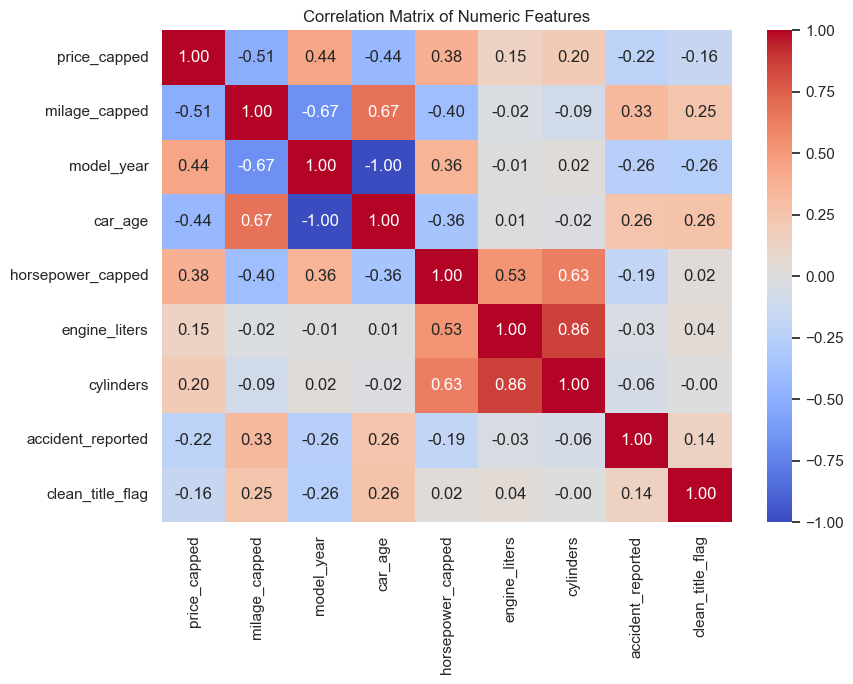

price_capped         1.000000
model_year           0.440168
horsepower_capped    0.376574
cylinders            0.201073
engine_liters        0.145250
clean_title_flag    -0.162765
accident_reported   -0.221055
car_age             -0.440168
milage_capped       -0.510310
Name: price_capped, dtype: float64

In [14]:
numeric_cols = ['price_capped', 'milage_capped', 'model_year', 'car_age',
                 'horsepower_capped', 'engine_liters', 'cylinders',
                 'accident_reported', 'clean_title_flag']
corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

corr['price_capped'].sort_values(ascending=False)

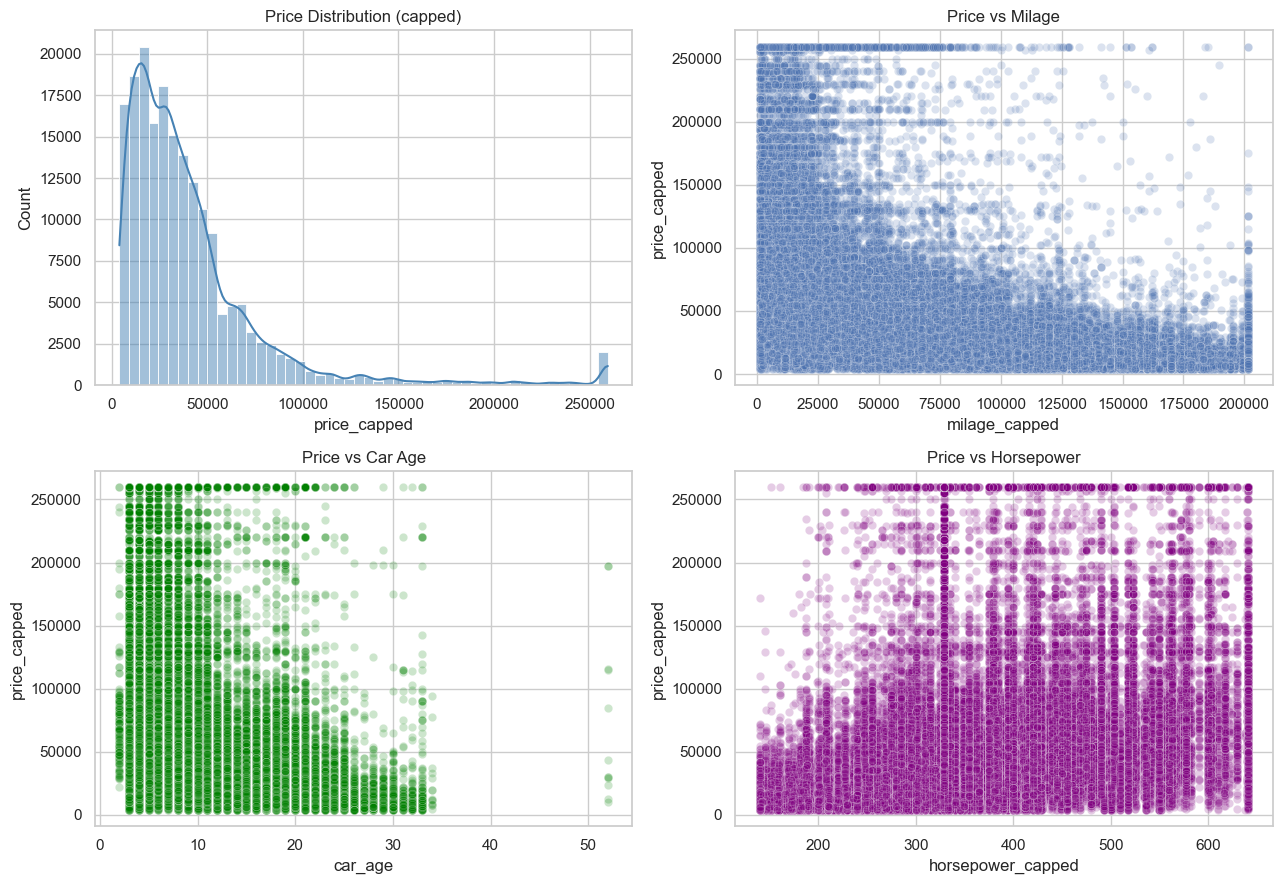

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(df['price_capped'], bins=50, kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Price Distribution (capped)')

sns.scatterplot(x=df['milage_capped'], y=df['price_capped'], alpha=0.2, ax=axes[0,1])
axes[0,1].set_title('Price vs Milage')

sns.scatterplot(x=df['car_age'], y=df['price_capped'], alpha=0.2, ax=axes[1,0], color='green')
axes[1,0].set_title('Price vs Car Age')

sns.scatterplot(x=df['horsepower_capped'], y=df['price_capped'], alpha=0.2, ax=axes[1,1], color='purple')
axes[1,1].set_title('Price vs Horsepower')

plt.tight_layout()
plt.show()

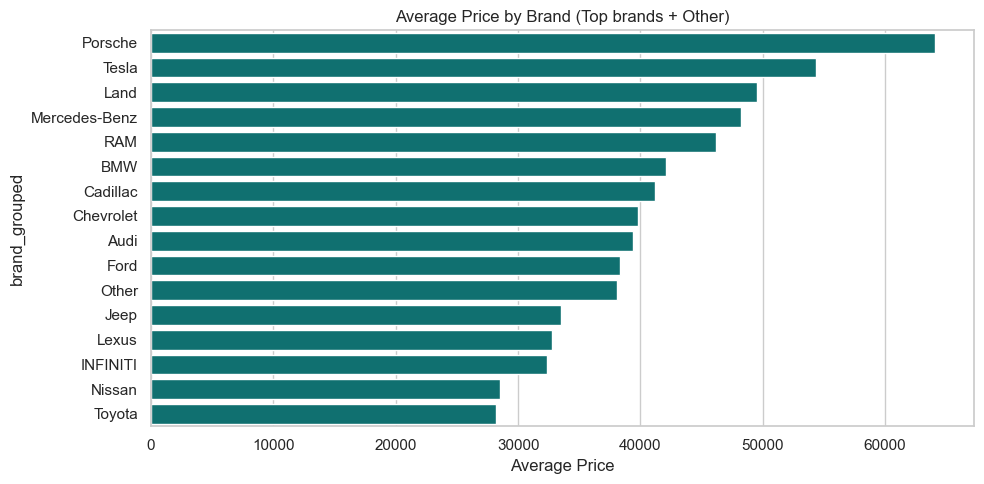

In [16]:
brand_price = df.groupby('brand_grouped')['price_capped'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=brand_price.values, y=brand_price.index, color='teal')
plt.xlabel('Average Price')
plt.title('Average Price by Brand (Top brands + Other)')
plt.tight_layout()
plt.show()

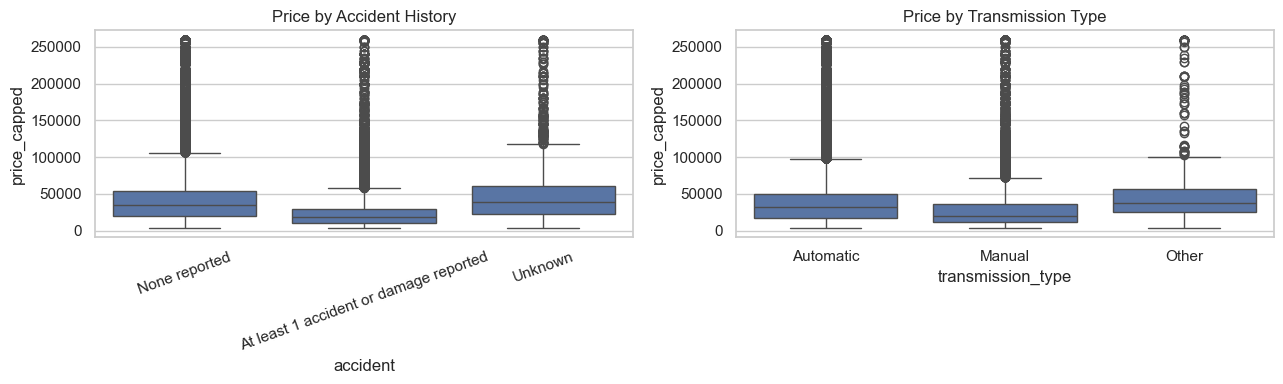

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(x='accident', y='price_capped', data=df, ax=axes[0])
axes[0].set_title('Price by Accident History')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(x='transmission_type', y='price_capped', data=df, ax=axes[1])
axes[1].set_title('Price by Transmission Type')
plt.tight_layout()
plt.show()

In [18]:
model_df = df.copy()

encoded = pd.get_dummies(model_df[['brand_grouped', 'fuel_type', 'transmission_type']],
                          drop_first=True)

features_numeric = ['milage_capped', 'car_age', 'horsepower_capped', 'engine_liters',
                     'cylinders', 'accident_reported', 'clean_title_flag']

X_full = pd.concat([model_df[features_numeric], encoded], axis=1)
y = model_df['price_capped']

print("Feature matrix shape:", X_full.shape)
X_full.head()

Feature matrix shape: (188533, 30)


,milage_capped,car_age,horsepower_capped,engine_liters,cylinders,accident_reported,clean_title_flag,brand_grouped_BMW,brand_grouped_Cadillac,brand_grouped_Chevrolet,brand_grouped_Ford,brand_grouped_INFINITI,brand_grouped_Jeep,brand_grouped_Land,brand_grouped_Lexus,brand_grouped_Mercedes-Benz,brand_grouped_Nissan,brand_grouped_Other,brand_grouped_Porsche,brand_grouped_RAM,brand_grouped_Tesla,brand_grouped_Toyota,fuel_type_E85 Flex Fuel,fuel_type_Gasoline,fuel_type_Hybrid,fuel_type_Plug-In Hybrid,fuel_type_Unknown,fuel_type_not supported,transmission_type_Manual,transmission_type_Other
0,201509,19,172.0,1.6,4.0,0,1,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False
1,143250,24,252.0,3.9,8.0,1,1,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False
2,136731,24,320.0,5.3,8.0,0,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
3,19500,9,420.0,5.0,8.0,0,1,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False
4,7388,5,208.0,2.0,4.0,0,1,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False


In [19]:
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42
)
print("Train size:", X_train_full.shape, "Test size:", X_test_full.shape)

Train size: (150826, 30) Test size: (37707, 30)


In [20]:
X_train_slr = X_train_full[['milage_capped']]
X_test_slr = X_test_full[['milage_capped']]

slr = LinearRegression()
slr.fit(X_train_slr, y_train)
pred_slr = slr.predict(X_test_slr)

r2_slr = r2_score(y_test, pred_slr)
mae_slr = mean_absolute_error(y_test, pred_slr)
rmse_slr = np.sqrt(mean_squared_error(y_test, pred_slr))

print("Simple Linear Regression (price ~ milage)")
print(f"Coefficient (slope): {slr.coef_[0]:.4f}")
print(f"Intercept: {slr.intercept_:.4f}")
print(f"R2: {r2_slr:.4f}  MAE: {mae_slr:.2f}  RMSE: {rmse_slr:.2f}")

Simple Linear Regression (price ~ milage)
Coefficient (slope): -0.4200
Intercept: 68629.6125
R2: 0.2551  MAE: 20726.40  RMSE: 34935.39


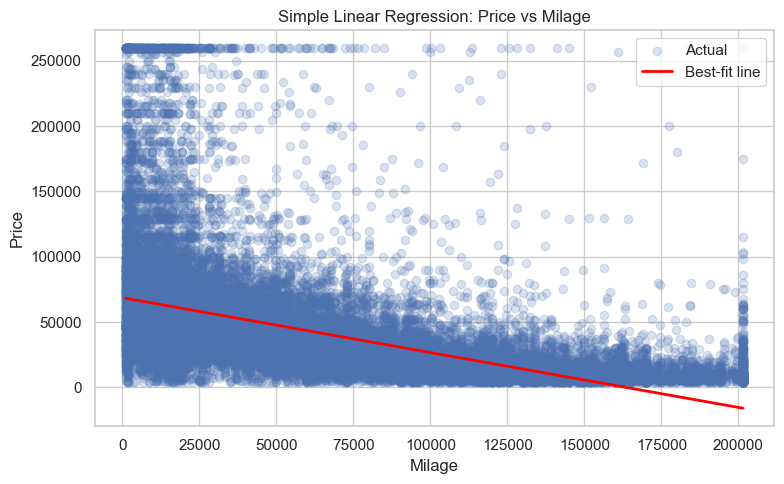

In [21]:
plt.figure(figsize=(8, 5))
plt.scatter(X_test_slr['milage_capped'], y_test, alpha=0.2, label='Actual')
order = np.argsort(X_test_slr['milage_capped'].values)
plt.plot(X_test_slr['milage_capped'].values[order], pred_slr[order], color='red', linewidth=2, label='Best-fit line')
plt.xlabel('Milage')
plt.ylabel('Price')
plt.title('Simple Linear Regression: Price vs Milage')
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
mlr = LinearRegression()
mlr.fit(X_train_full, y_train)
pred_mlr = mlr.predict(X_test_full)

r2_mlr = r2_score(y_test, pred_mlr)
mae_mlr = mean_absolute_error(y_test, pred_mlr)
rmse_mlr = np.sqrt(mean_squared_error(y_test, pred_mlr))

print("Multiple Linear Regression (all features)")
print(f"R2: {r2_mlr:.4f}  MAE: {mae_mlr:.2f}  RMSE: {rmse_mlr:.2f}")

coef_table = pd.DataFrame({
    'feature': X_train_full.columns,
    'coefficient': mlr.coef_
}).sort_values('coefficient', key=abs, ascending=False)
coef_table.head(15)

Multiple Linear Regression (all features)
R2: 0.3252  MAE: 19079.13  RMSE: 33252.09


,feature,coefficient
18,brand_grouped_Porsche,17723.105913
19,brand_grouped_RAM,-8778.403748
25,fuel_type_Plug-In Hybrid,-7603.063654
22,fuel_type_E85 Flex Fuel,-6854.757099
27,fuel_type_not supported,-6851.024920
11,brand_grouped_INFINITI,-6478.941471
20,brand_grouped_Tesla,-6462.343996
29,transmission_type_Other,6228.925536
9,brand_grouped_Chevrolet,-5918.388693
23,fuel_type_Gasoline,-4540.653782


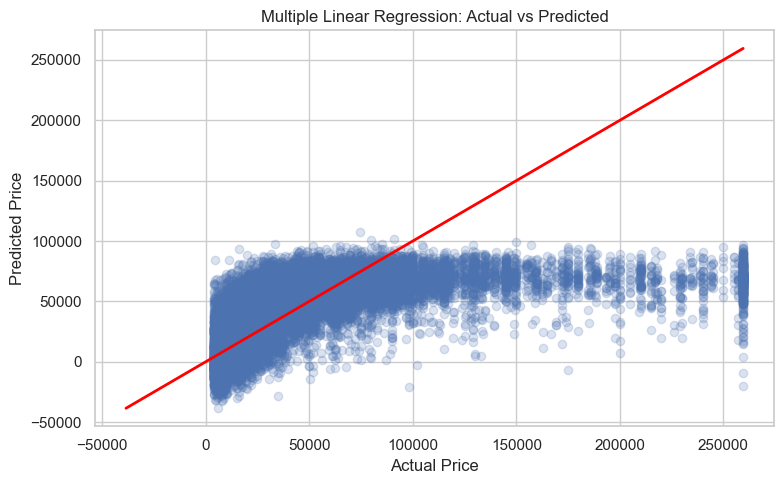

In [23]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, pred_mlr, alpha=0.2)
lims = [min(y_test.min(), pred_mlr.min()), max(y_test.max(), pred_mlr.max())]
plt.plot(lims, lims, color='red', linewidth=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Multiple Linear Regression: Actual vs Predicted')
plt.tight_layout()
plt.show()

In [24]:
degree = 2
poly = PolynomialFeatures(degree=degree)

X_train_poly = poly.fit_transform(X_train_full[['milage_capped']])
X_test_poly = poly.transform(X_test_full[['milage_capped']])

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)
pred_poly = poly_reg.predict(X_test_poly)

r2_poly = r2_score(y_test, pred_poly)
mae_poly = mean_absolute_error(y_test, pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, pred_poly))

print(f"Polynomial Regression (degree={degree}, price ~ milage)")
print(f"R2: {r2_poly:.4f}  MAE: {mae_poly:.2f}  RMSE: {rmse_poly:.2f}")

Polynomial Regression (degree=2, price ~ milage)
R2: 0.3070  MAE: 18888.89  RMSE: 33697.84


c:\Users\baqar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


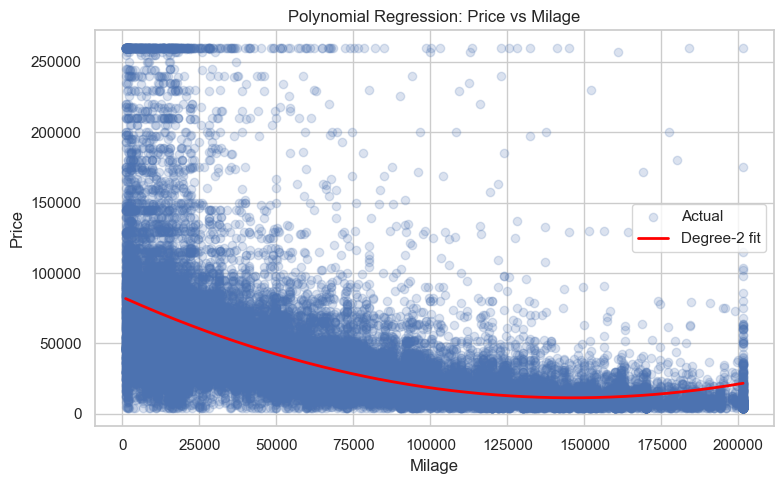

In [25]:
plt.figure(figsize=(8, 5))
plt.scatter(X_test_full['milage_capped'], y_test, alpha=0.2, label='Actual')
x_range = np.linspace(X_test_full['milage_capped'].min(), X_test_full['milage_capped'].max(), 300).reshape(-1, 1)
x_range_poly = poly.transform(x_range)
y_range_pred = poly_reg.predict(x_range_poly)
plt.plot(x_range, y_range_pred, color='red', linewidth=2, label=f'Degree-{degree} fit')
plt.xlabel('Milage')
plt.ylabel('Price')
plt.title('Polynomial Regression: Price vs Milage')
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
results = pd.DataFrame({
    'Model': ['Simple Linear Regression', 'Multiple Linear Regression', 'Polynomial Regression (deg 2)'],
    'R2': [r2_slr, r2_mlr, r2_poly],
    'MAE': [mae_slr, mae_mlr, mae_poly],
    'RMSE': [rmse_slr, rmse_mlr, rmse_poly]
})
results

,Model,R2,MAE,RMSE
0,Simple Linear Regression,0.255144,20726.400716,34935.387669
1,Multiple Linear Regression,0.325194,19079.128572,33252.092762
2,Polynomial Regression (deg 2),0.306981,18888.885607,33697.839798


C:\Users\baqar\AppData\Local\Temp\ipykernel_15460\4011095795.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=results, ax=ax, palette='viridis')
C:\Users\baqar\AppData\Local\Temp\ipykernel_15460\4011095795.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=results, ax=ax, palette='viridis')
C:\Users\baqar\AppData\Local\Temp\ipykernel_15460\4011095795.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=results, ax=ax, palette='viridis')


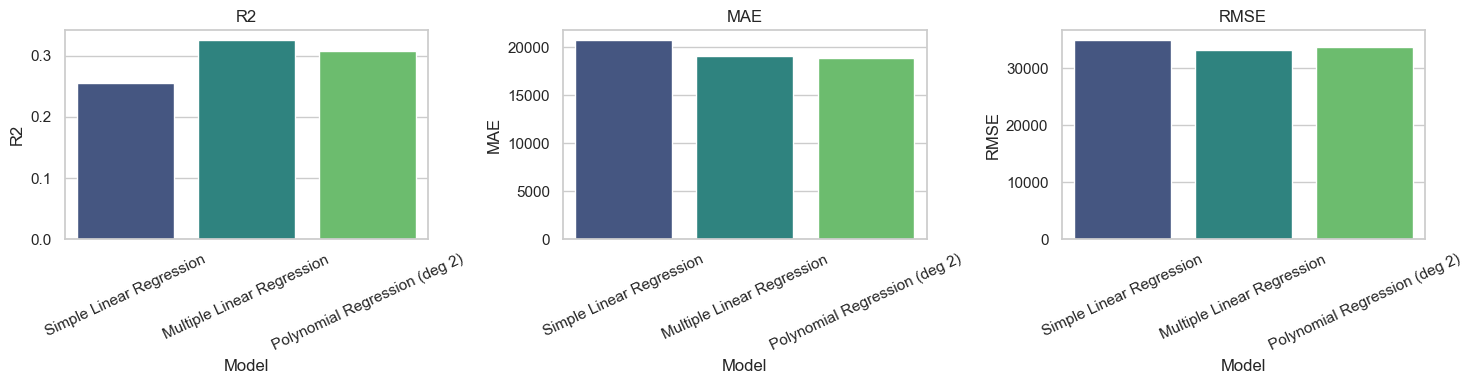

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['R2', 'MAE', 'RMSE']):
    sns.barplot(x='Model', y=metric, data=results, ax=ax, palette='viridis')
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

In [28]:
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import KFold

test_raw = pd.read_csv('test.csv')
sample_sub = pd.read_csv('sample_submission.csv')

train_raw = pd.read_csv('train.csv')
train_raw['is_train'] = 1
test_raw['is_train'] = 0
test_raw['price'] = np.nan
full = pd.concat([train_raw, test_raw], axis=0, ignore_index=True)

full['car_age'] = CURRENT_YEAR - full['model_year']
full['horsepower'] = full['engine'].apply(extract_hp)
full['engine_liters'] = full['engine'].apply(extract_liters)
full['cylinders'] = full['engine'].apply(extract_cylinders)
for c in ['horsepower', 'engine_liters', 'cylinders']:
    full[c] = full[c].fillna(full[c].median())

full['fuel_type'] = full['fuel_type'].replace('\u2013', np.nan).fillna('Unknown')
full['accident'] = full['accident'].fillna('Unknown')
full['clean_title'] = full['clean_title'].fillna('Unknown')
full['accident_reported'] = (full['accident'] == 'At least 1 accident or damage reported').astype(int)
full['clean_title_flag'] = (full['clean_title'] == 'Yes').astype(int)
full['transmission_type'] = full['transmission'].apply(simplify_transmission)

gbm_cat_features = ['brand', 'model', 'fuel_type', 'transmission_type', 'ext_col', 'int_col']
for c in gbm_cat_features:
    full[c] = full[c].fillna('Unknown').astype(str).astype('category')

gbm_num_features = ['milage', 'car_age', 'horsepower', 'engine_liters', 'cylinders',
                     'accident_reported', 'clean_title_flag']
gbm_feature_cols = gbm_cat_features + gbm_num_features

train_gbm = full[full['is_train'] == 1].reset_index(drop=True)
test_gbm = full[full['is_train'] == 0].reset_index(drop=True)

y_log = np.log1p(train_gbm['price'].values)   
X_gbm = train_gbm[gbm_feature_cols].copy()
X_test_gbm = test_gbm[gbm_feature_cols].copy()
test_ids = test_gbm['id'].values

print("Train features:", X_gbm.shape, " Test features:", X_test_gbm.shape)

Train features: (188533, 13)  Test features: (125690, 13)


In [29]:
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

oof_lgb = np.zeros(len(X_gbm))
oof_xgb = np.zeros(len(X_gbm))
test_pred_lgb = np.zeros(len(X_test_gbm))
test_pred_xgb = np.zeros(len(X_test_gbm))

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_gbm)):
    X_tr, X_val = X_gbm.iloc[tr_idx], X_gbm.iloc[val_idx]
    y_tr, y_val = y_log[tr_idx], y_log[val_idx]

    lgb_train = lgb.Dataset(X_tr, y_tr, categorical_feature=gbm_cat_features)
    lgb_val = lgb.Dataset(X_val, y_val, categorical_feature=gbm_cat_features, reference=lgb_train)
    lgbm = lgb.train(
        {'objective': 'regression', 'metric': 'rmse', 'learning_rate': 0.05,
         'num_leaves': 64, 'min_data_in_leaf': 20, 'verbose': -1, 'seed': 42},
        lgb_train, num_boost_round=3000, valid_sets=[lgb_val],
        callbacks=[lgb.early_stopping(100, verbose=False)]
    )
    oof_lgb[val_idx] = lgbm.predict(X_val)
    test_pred_lgb += lgbm.predict(X_test_gbm) / n_splits

    dtrain = xgb.DMatrix(X_tr, label=y_tr, enable_categorical=True)
    dval = xgb.DMatrix(X_val, label=y_val, enable_categorical=True)
    dtest = xgb.DMatrix(X_test_gbm, enable_categorical=True)
    params = {'objective': 'reg:squarederror', 'eta': 0.05, 'max_depth': 8,
              'tree_method': 'hist', 'seed': 42}
    bst = xgb.train(params, dtrain, num_boost_round=3000, evals=[(dval, 'val')],
                     early_stopping_rounds=100, verbose_eval=False)
    oof_xgb[val_idx] = bst.predict(dval, iteration_range=(0, bst.best_iteration + 1))
    test_pred_xgb += bst.predict(dtest, iteration_range=(0, bst.best_iteration + 1)) / n_splits

    print(f"Fold {fold}: lgb_best_iter={lgbm.best_iteration}, xgb_best_iter={bst.best_iteration}")

Fold 0: lgb_best_iter=92, xgb_best_iter=85
Fold 1: lgb_best_iter=99, xgb_best_iter=79
Fold 2: lgb_best_iter=88, xgb_best_iter=80
Fold 3: lgb_best_iter=88, xgb_best_iter=89
Fold 4: lgb_best_iter=94, xgb_best_iter=83


In [30]:
def rmse_orig(y_true_log, y_pred_log):
    return np.sqrt(mean_squared_error(np.expm1(y_true_log), np.expm1(y_pred_log)))

rmse_lgb = rmse_orig(y_log, oof_lgb)
rmse_xgb = rmse_orig(y_log, oof_xgb)

best_w, best_blend_rmse = 0.5, np.inf
for w in np.arange(0.0, 1.01, 0.05):
    r = rmse_orig(y_log, w * oof_lgb + (1 - w) * oof_xgb)
    if r < best_blend_rmse:
        best_blend_rmse, best_w = r, w

print(f"LightGBM  5-fold CV RMSE: {rmse_lgb:,.2f}")
print(f"XGBoost   5-fold CV RMSE: {rmse_xgb:,.2f}")
print(f"Blend ({best_w:.2f}*LGB + {1-best_w:.2f}*XGB) CV RMSE: {best_blend_rmse:,.2f}")

LightGBM  5-fold CV RMSE: 73,452.03
XGBoost   5-fold CV RMSE: 73,647.26
Blend (1.00*LGB + 0.00*XGB) CV RMSE: 73,452.03


In [31]:
final_test_pred_log = best_w * test_pred_lgb + (1 - best_w) * test_pred_xgb
final_test_pred = np.expm1(final_test_pred_log)      
final_test_pred = np.clip(final_test_pred, 0, None)  

submission = pd.DataFrame({'id': test_ids, 'price': final_test_pred})
submission = submission[sample_sub.columns.tolist()]  
submission.to_csv('submission.csv', index=False)

print("submission.csv shape:", submission.shape)
submission.head()

submission.csv shape: (125690, 2)


,id,price
0,188533,16763.475758
1,188534,64683.290664
2,188535,48427.466649
3,188536,26137.601109
4,188537,29564.467952


In [32]:
print("https://www.kaggle.com/competitions/playground-series-s4e9/overview")

https://www.kaggle.com/competitions/playground-series-s4e9/overview
